# 05 - EM-LDDMM Registration

Run EM-LDDMM on the prepared whole-slide tissue stack. This notebook is intentionally focused on atlas-free self-alignment and registration QC.

IEMap atlas-based registration is handled in the companion notebook [05b_iemap_atlas_registration.ipynb](05b_iemap_atlas_registration.ipynb). Between-slice upsampling remains here as an optional post-alignment appendix because it is only meaningful after self-alignment looks acceptable.

## Step 1: Setup and Parameters

In [1]:
from __future__ import annotations

import json
import shlex
from pathlib import Path

# Local non-Docker setup uses ../emlddmm as source code plus modern runtime deps.
# python -m pip install -c constraints.txt "h5py>=3.10" "nibabel>=5.0"
# python -m pip install --index-url https://download.pytorch.org/whl/cpu "torch==2.10.0+cpu"
# GPU option: uncomment only on an NVIDIA system with a compatible CUDA 12.8 driver.
# python -m pip install --index-url https://download.pytorch.org/whl/cu128 "torch==2.10.0+cu128"
from wsi_pipeline.emlddmm_prep import ensure_emlddmm_on_path

EMLDDMM_REPO = ensure_emlddmm_on_path("emlddmm")

import pandas as pd
from IPython.display import HTML, Image, JSON, display

from wsi_pipeline.registration import (
    plan_emlddmm_workflow,
    run_ea2d_self_alignment_sweep,
    run_emlddmm_workflow,
    summarize_ea2d_sweep,
)
from wsi_pipeline.registration.orientation import (
    list_valid_orientation_codes,
    orientation_validation_rule,
)
from wsi_pipeline.registration.targets import load_manifest

try:
    get_ipython().run_line_magic("load_ext", "autoreload")
    get_ipython().run_line_magic("autoreload", "2")
except NameError:
    pass

In [2]:
# Docker-friendly defaults. Edit these values for local paths.
DATASET_ROOT = Path("/cis/home/dpadova/Documents/temporal_bone_project/notebook_flatfile_smoke_level7/tissue_sections").expanduser()
TARGET_SOURCE = DATASET_ROOT
TARGET_SOURCE_FORMAT = "auto"  # auto, prepared-dir, or precomputed
PRECOMPUTED_MANIFEST = None
REGISTRATION_OUTPUT = DATASET_ROOT / "emlddmm"
EMLDDMM_CONFIG = None
PRESET = "macaque-notebook"
DEVICE = "auto"

# Run behavior. The default executes every enabled stage when inputs are valid.
RUN_REGISTRATION = True
DRY_RUN = False
WRITE_QC_REPORT = True
WRITE_NOTEBOOK_BUNDLE = False

# Optional eA2d-only atlas-free tuning ladder. Disabled by default because it runs multiple full self-alignments.
RUN_EA2D_SWEEP = True # False
EA2D_SWEEP_VALUES = [5e3, 1e4, 2e4, 5e4, 1e5]
EA2D_SWEEP_INCLUDE_STRESS = False
EA2D_SWEEP_OUTPUT = REGISTRATION_OUTPUT / "sweeps" / "ea2d"
EA2D_SWEEP_TOP_N = 6

# Atlas fields are kept disabled here. Use 05b_iemap_atlas_registration.ipynb for IEMap atlas registration.
ATLAS_PATH = None
LABEL_PATH = None
INIT_AFFINE_PATH = None
ORIENTATION_FROM = None
ORIENTATION_TO = None
ATLAS_UNIT_SCALE = None  # Preset default: 1000.0
TARGET_UNIT_SCALE = None  # Preset default: 1.0

# Optional between-slice filling and transformation graph execution.
# Enable upsampling only after alignment QC looks satisfactory.
UPSAMPLE_BETWEEN_SLICES = False # True, False
UPSAMPLE_MODE = "img"  # img for intensity slices, seg for discrete labels
RUN_TRANSFORMATION_GRAPH = False
TRANSFORMATION_GRAPH_SCRIPT = None

In [3]:
def optional_path(value):
    if value in (None, ""):
        return None
    return Path(value).expanduser()


atlas_path = optional_path(ATLAS_PATH)
label_path = optional_path(LABEL_PATH)
init_affine_path = optional_path(INIT_AFFINE_PATH)
precomputed_manifest = optional_path(PRECOMPUTED_MANIFEST)
emlddmm_config = optional_path(EMLDDMM_CONFIG)
transformation_graph_script = optional_path(TRANSFORMATION_GRAPH_SCRIPT)

if atlas_path is None:
    label_path = None
    init_affine_path = None
    orientation_from = None
    orientation_to = None
else:
    orientation_from = ORIENTATION_FROM.upper() if ORIENTATION_FROM else None
    orientation_to = ORIENTATION_TO.upper() if ORIENTATION_TO else None
    if init_affine_path is None and not (orientation_from and orientation_to):
        raise ValueError(
            "Atlas registration requires INIT_AFFINE_PATH or both "
            "ORIENTATION_FROM and ORIENTATION_TO. No orientation guess is applied."
        )

workflow_kwargs = {
    "dataset_root": DATASET_ROOT,
    "target_source": TARGET_SOURCE,
    "target_source_format": TARGET_SOURCE_FORMAT,
    "registration_output": REGISTRATION_OUTPUT,
    "atlas": atlas_path,
    "label": label_path,
    "emlddmm_config": emlddmm_config,
    "preset": PRESET,
    "init_affine": init_affine_path,
    "orientation_from": orientation_from,
    "orientation_to": orientation_to,
    "atlas_unit_scale": ATLAS_UNIT_SCALE,
    "target_unit_scale": TARGET_UNIT_SCALE,
    "device": DEVICE,
    "precomputed_manifest": precomputed_manifest,
    "upsample_between_slices": UPSAMPLE_BETWEEN_SLICES,
    "upsample_mode": UPSAMPLE_MODE if UPSAMPLE_BETWEEN_SLICES else None,
    "run_transformation_graph": RUN_TRANSFORMATION_GRAPH,
    "transformation_graph_script": transformation_graph_script,
    "write_notebook_bundle": WRITE_NOTEBOOK_BUNDLE,
    "write_qc_report": WRITE_QC_REPORT,
}

print(orientation_validation_rule())
print("Example valid orientation codes:", ", ".join(list_valid_orientation_codes()[:8]), "...")

Orientation codes must be exactly 3 letters and use one axis from each pair {R/L}, {A/P}, and {S/I}, with no duplicate anatomical axes.
Example valid orientation codes: AIL, AIR, ALI, ALS, ARI, ARS, ASL, ASR ...


## Step 2: Validate Pipeline Step 4 Handoff

In [4]:
samples_tsv = DATASET_ROOT / "samples.tsv"
manifest_path = precomputed_manifest or (DATASET_ROOT / "emlddmm_dataset_manifest.json")
sidecars = sorted(
    path
    for path in DATASET_ROOT.glob("*.json")
    if path.name != "emlddmm_dataset_manifest.json"
)

missing = [path for path in (samples_tsv, manifest_path) if path is not None and not path.exists()]
if missing:
    raise FileNotFoundError("Missing Step 4 output(s): " + ", ".join(str(path) for path in missing))
if not sidecars:
    raise FileNotFoundError(f"No per-slice JSON sidecars found in {DATASET_ROOT}")

print(f"Dataset root:        {DATASET_ROOT}")
print(f"samples.tsv:         {samples_tsv}")
print(f"Manifest:            {manifest_path}")
print(f"Sidecar JSON files:  {len(sidecars)}")
print(f"Registration output: {REGISTRATION_OUTPUT}")

Dataset root:        /cis/home/dpadova/Documents/temporal_bone_project/notebook_flatfile_smoke_level7/tissue_sections
samples.tsv:         /cis/home/dpadova/Documents/temporal_bone_project/notebook_flatfile_smoke_level7/tissue_sections/samples.tsv
Manifest:            /cis/home/dpadova/Documents/temporal_bone_project/notebook_flatfile_smoke_level7/tissue_sections/emlddmm_dataset_manifest.json
Sidecar JSON files:  46
Registration output: /cis/home/dpadova/Documents/temporal_bone_project/notebook_flatfile_smoke_level7/tissue_sections/emlddmm


## Step 3: Preview Target Manifest

In [5]:
manifest = load_manifest(manifest_path)
entries = list(manifest.get("entries", []))

def is_present(entry):
    return str(entry.get("status", "")).strip().lower() in {"present", "true", "1"}


present_count = sum(1 for entry in entries if is_present(entry))
missing_count = len(entries) - present_count

overview = {
    "space": manifest.get("space"),
    "dv_um": manifest.get("dv_um"),
    "z_axis_um": manifest.get("z_axis_um"),
    "full_grid_count": manifest.get("full_grid_count"),
    "dense_present_count": manifest.get("dense_present_count"),
    "present_count_from_entries": present_count,
    "missing_count_from_entries": missing_count,
    "target_ext": manifest.get("target_ext"),
}
display(JSON(overview, expanded=True))

preview_columns = [
    "grid_index",
    "present_rank",
    "sample_id",
    "status",
    "image_filename",
    "z_position_um",
]
preview_rows = [{column: entry.get(column) for column in preview_columns} for entry in entries[:12]]
display(pd.DataFrame(preview_rows))

<IPython.core.display.JSON object>

,grid_index,present_rank,sample_id,status,image_filename,z_position_um
0,0,0.0,level_7_Image_00_00_0001.tif,present,level_7_Image_00_00_0001.tif,-3600.0
1,1,NaN,level_7_Image_00_00_0002.tif,missing,level_7_Image_00_00_0002.tif,-3584.0
2,2,NaN,level_7_Image_00_00_0003.tif,missing,level_7_Image_00_00_0003.tif,-3568.0
3,3,NaN,level_7_Image_00_00_0004.tif,missing,level_7_Image_00_00_0004.tif,-3552.0
4,4,NaN,level_7_Image_00_00_0005.tif,missing,level_7_Image_00_00_0005.tif,-3536.0
5,5,NaN,level_7_Image_00_00_0006.tif,missing,level_7_Image_00_00_0006.tif,-3520.0
6,6,NaN,level_7_Image_00_00_0007.tif,missing,level_7_Image_00_00_0007.tif,-3504.0
7,7,NaN,level_7_Image_00_00_0008.tif,missing,level_7_Image_00_00_0008.tif,-3488.0
8,8,NaN,level_7_Image_00_00_0009.tif,missing,level_7_Image_00_00_0009.tif,-3472.0
9,9,NaN,level_7_Image_00_00_0010.tif,missing,level_7_Image_00_00_0010.tif,-3456.0


## Step 4: Resolve the Step 5 Run Plan

use display False


<IPython.core.display.JSON object>

<IPython.core.display.JSON object>

Warnings:
- Using default target_unit_scale=1.0; target coordinates are assumed to already be micrometers.


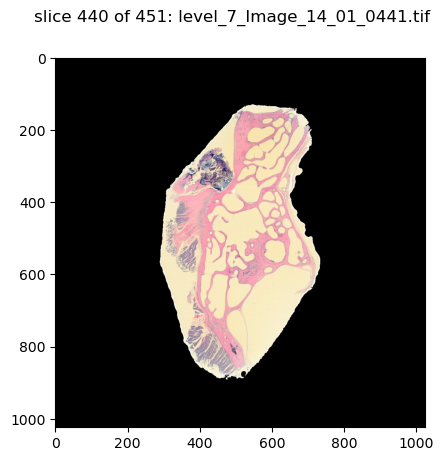

In [6]:
resolved_plan = plan_emlddmm_workflow(**workflow_kwargs, dry_run=True)

plan_overview = {
    "mode": resolved_plan.mode,
    "backend": resolved_plan.backend_name,
    "target_source": str(resolved_plan.target_source),
    "target_source_format": resolved_plan.target_source_format,
    "registration_output": str(resolved_plan.registration_output),
    "atlas_path": str(resolved_plan.atlas_path) if resolved_plan.atlas_path else None,
    "label_path": str(resolved_plan.label_path) if resolved_plan.label_path else None,
    "device_requested": resolved_plan.device_requested,
    "device_used": resolved_plan.device_used,
    "atlas_init_mode": resolved_plan.atlas_init_mode,
    "enabled_stages": resolved_plan.enabled_stages,
    "skipped_stages": resolved_plan.skipped_stages,
    "working_resolution_um": resolved_plan.working_resolution_um,
    "target_downsampling": resolved_plan.target_downsampling,
    "atlas_downsampling": resolved_plan.atlas_downsampling,
}
display(JSON(plan_overview, expanded=True))
display(JSON(resolved_plan.pre_resampling_plan.model_dump(mode="python"), expanded=True))

if resolved_plan.warnings:
    print("Warnings:")
    for warning in resolved_plan.warnings:
        print(f"- {warning}")

## Step 5: CLI Replay Command

In [7]:
def append_path_arg(args, flag, value):
    value = optional_path(value)
    if value is not None:
        args.extend([flag, str(value)])


cli_args = [
    "python",
    "scripts/run_pipeline.py",
    "step5",
    "--dataset-root",
    str(DATASET_ROOT),
    "--target-source",
    str(TARGET_SOURCE),
    "--target-source-format",
    TARGET_SOURCE_FORMAT,
    "--registration-output",
    str(REGISTRATION_OUTPUT),
    "--preset",
    PRESET,
]
append_path_arg(cli_args, "--emlddmm-config", emlddmm_config)
append_path_arg(cli_args, "--atlas", atlas_path)
append_path_arg(cli_args, "--label", label_path)
append_path_arg(cli_args, "--init-affine", init_affine_path)
append_path_arg(cli_args, "--precomputed-manifest", precomputed_manifest)
append_path_arg(cli_args, "--transformation-graph-script", transformation_graph_script)

if orientation_from and orientation_to:
    cli_args.extend(["--orientation-from", orientation_from, "--orientation-to", orientation_to])
if ATLAS_UNIT_SCALE is not None:
    cli_args.extend(["--atlas-unit-scale", str(ATLAS_UNIT_SCALE)])
if TARGET_UNIT_SCALE is not None:
    cli_args.extend(["--target-unit-scale", str(TARGET_UNIT_SCALE)])
if DEVICE:
    cli_args.extend(["--device", DEVICE])
if UPSAMPLE_BETWEEN_SLICES:
    cli_args.extend(["--upsample-between-slices", "--upsample-mode", UPSAMPLE_MODE])
if RUN_TRANSFORMATION_GRAPH:
    cli_args.append("--run-transformation-graph")
if WRITE_QC_REPORT:
    cli_args.append("--write-qc-report")
if WRITE_NOTEBOOK_BUNDLE:
    cli_args.append("--write-notebook-bundle")
if DRY_RUN:
    cli_args.append("--dry-run")

line_join = " " + "\\" + "\n  "
print(line_join.join(shlex.quote(part) for part in cli_args))

python \
  scripts/run_pipeline.py \
  step5 \
  --dataset-root \
  /cis/home/dpadova/Documents/temporal_bone_project/notebook_flatfile_smoke_level7/tissue_sections \
  --target-source \
  /cis/home/dpadova/Documents/temporal_bone_project/notebook_flatfile_smoke_level7/tissue_sections \
  --target-source-format \
  auto \
  --registration-output \
  /cis/home/dpadova/Documents/temporal_bone_project/notebook_flatfile_smoke_level7/tissue_sections/emlddmm \
  --preset \
  macaque-notebook \
  --device \
  auto \
  --write-qc-report


## Step 6: Run Registration

/cis/home/dpadova/Documents/git/emlddmm/emlddmm.py:5330: RuntimeWarning: divide by zero encountered in divide
  op = 1.0 / (xJ[0] - xJ[0][0])
/cis/home/dpadova/Documents/git/emlddmm/emlddmm.py:5332: RuntimeWarning: divide by zero encountered in divide
  op = 1.0 / (xJ[0] - xJ[0][0])**2
/cis/home/dpadova/Documents/git/emlddmm/emlddmm.py:5333: RuntimeWarning: divide by zero encountered in divide
  op = 1.0 / np.abs((xJ[0] - xJ[0][0]))**1.5/np.sign((xJ[0] - xJ[0][0]))


starting it 0
starting it 1


/cis/home/dpadova/Documents/git/emlddmm/emlddmm.py:1514: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  A2d = torch.tensor(A2d.detach().clone(),device=device, dtype=dtype)


starting it 2
starting it 3
starting it 4
starting it 5
starting it 6
starting it 7
starting it 8
starting it 9
Mode:         atlas_free
Plan JSON:    /cis/home/dpadova/Documents/temporal_bone_project/notebook_flatfile_smoke_level7/tissue_sections/emlddmm/resolved_run_plan.json
Summary JSON: /cis/home/dpadova/Documents/temporal_bone_project/notebook_flatfile_smoke_level7/tissue_sections/emlddmm/registration_summary.json
Log file:     /cis/home/dpadova/Documents/temporal_bone_project/notebook_flatfile_smoke_level7/tissue_sections/emlddmm/registration.log
Provenance:   /cis/home/dpadova/Documents/temporal_bone_project/notebook_flatfile_smoke_level7/tissue_sections/emlddmm/run_provenance.json
Replay cmd:   /cis/home/dpadova/Documents/temporal_bone_project/notebook_flatfile_smoke_level7/tissue_sections/emlddmm/reproduce_step5_command.txt
QC report:    /cis/home/dpadova/Documents/temporal_bone_project/notebook_flatfile_smoke_level7/tissue_sections/emlddmm/registration_report.html


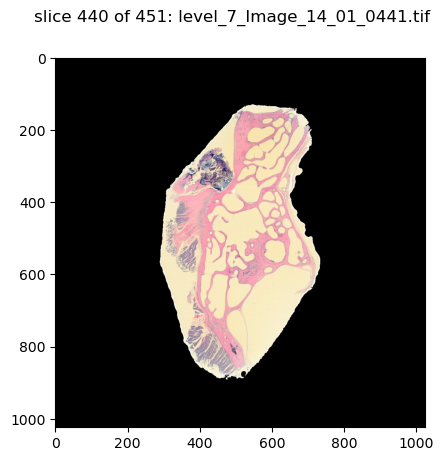

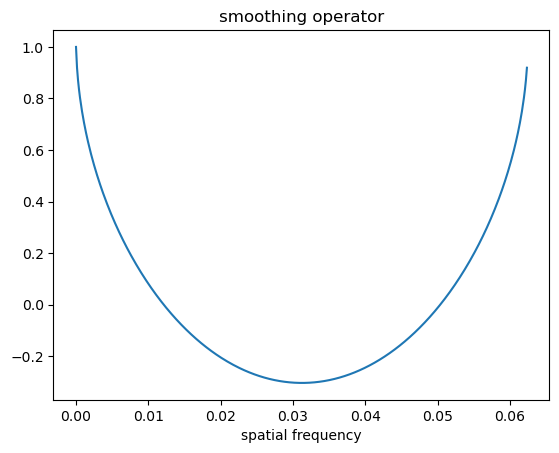

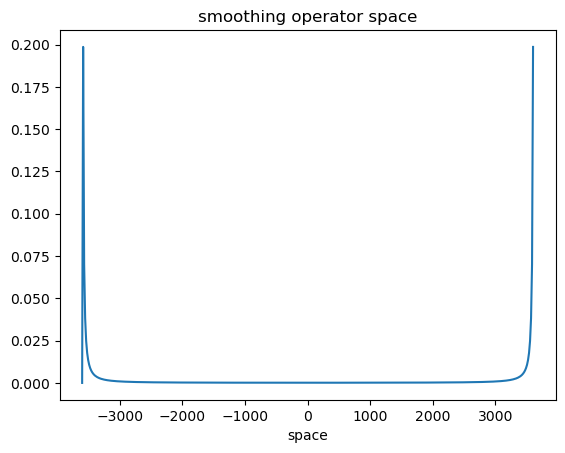

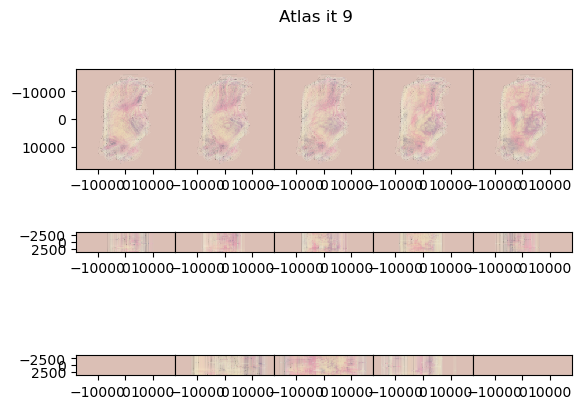

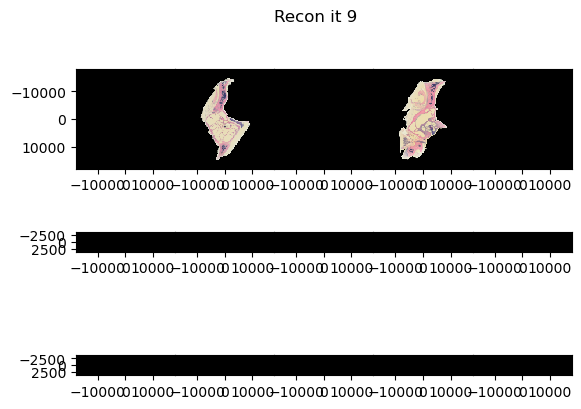

In [8]:
if RUN_REGISTRATION:
    result = run_emlddmm_workflow(**workflow_kwargs, dry_run=DRY_RUN)
    print(f"Mode:         {result.mode}")
    print(f"Plan JSON:    {result.plan_path}")
    print(f"Summary JSON: {result.summary_path}")
    print(f"Log file:     {result.log_path}")
    if result.provenance_path is not None:
        print(f"Provenance:   {result.provenance_path}")
    if result.reproduce_command_path is not None:
        print(f"Replay cmd:   {result.reproduce_command_path}")
    if result.report_path is not None:
        print(f"QC report:    {result.report_path}")
else:
    result = None
    print("RUN_REGISTRATION is False; resolved_plan is available for inspection.")

## Step 7: Review Summary and Artifacts

In [9]:
summary_path = result.summary_path if result is not None else REGISTRATION_OUTPUT / "registration_summary.json"
if summary_path.exists():
    summary = json.loads(summary_path.read_text(encoding="utf-8"))
    summary_overview = {
        key: summary.get(key)
        for key in (
            "mode",
            "backend_name",
            "device_used",
            "atlas_init_mode",
            "enabled_stages",
            "completed_stages",
            "skipped_stages",
            "warnings",
        )
    }
    display(JSON(summary_overview, expanded=True))
    display(pd.DataFrame(summary.get("stage_timeline", [])))
else:
    print(f"No summary found yet: {summary_path}")

<IPython.core.display.JSON object>

,name,enabled,status,started_at,ended_at,duration_seconds,reason,output_dir
0,self_alignment,True,completed,2026-05-12T18:26:51.802370+00:00,2026-05-12T18:31:34.647045+00:00,282.844658,None,/cis/home/dpadova/Documents/temporal_bone_proj...
1,atlas_registration,False,skipped,None,None,NaN,no atlas provided,/cis/home/dpadova/Documents/temporal_bone_proj...
2,upsampling,False,skipped,None,None,NaN,not requested,/cis/home/dpadova/Documents/temporal_bone_proj...


In [10]:
report_path = REGISTRATION_OUTPUT / "registration_report.html"
report_manifest_path = REGISTRATION_OUTPUT / "registration_report.json"
replay_path = REGISTRATION_OUTPUT / "reproduce_step5_command.txt"
log_path = REGISTRATION_OUTPUT / "registration.log"

if report_path.exists():
    display(HTML(f'<p><strong>QC report:</strong> <a href="{report_path}" target="_blank">{report_path}</a></p>'))
if replay_path.exists():
    print("Replay command:")
    print(replay_path.read_text(encoding="utf-8"))
if log_path.exists():
    print("Last 60 log lines:")
    print("\n".join(log_path.read_text(encoding="utf-8").splitlines()[-60:]))

Replay command:
/cis/home/dpadova/miniconda3/envs/wsi-pipeline/bin/python scripts/run_pipeline.py step5 --dataset-root /cis/home/dpadova/Documents/temporal_bone_project/notebook_flatfile_smoke_level7/tissue_sections --precomputed-manifest /cis/home/dpadova/Documents/temporal_bone_project/notebook_flatfile_smoke_level7/tissue_sections/emlddmm_dataset_manifest.json --write-qc-report

Last 60 log lines:
2026-05-08 17:13:40,229 INFO wsi_pipeline.registration.workflow: Resolved registration backend: installed:emlddmm
2026-05-08 17:14:13,225 INFO wsi_pipeline.registration.workflow: Target source resolved to /cis/home/dpadova/Documents/temporal_bone_project/notebook_flatfile_smoke_level7/tissue_sections (prepared-dir)
2026-05-08 17:14:13,225 INFO wsi_pipeline.registration.workflow: Atlas mode=atlas_free init_mode=none
2026-05-08 17:14:13,225 INFO wsi_pipeline.registration.workflow: Units atlas=1000.0 target=1.0 working_resolution_um=200.0
2026-05-08 17:14:13,225 INFO wsi_pipeline.registration

self_alignment: completed (3 report image(s))
  Input target before self-alignment. Tiles show evenly spaced present z-slices; channels are averaged and contrast is normalized per tile.


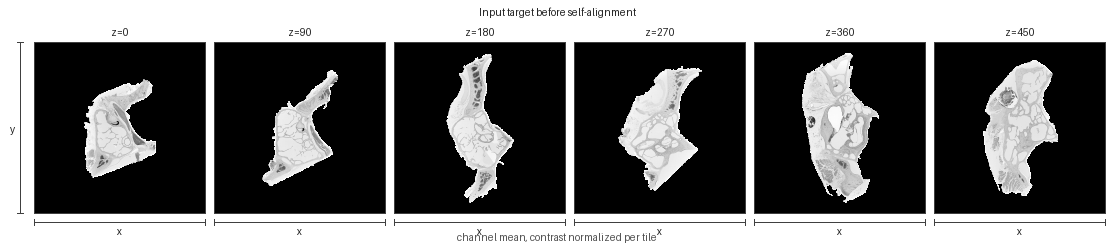

  Target after atlas-free self-alignment. Compare slice-to-slice continuity against the input target montage.


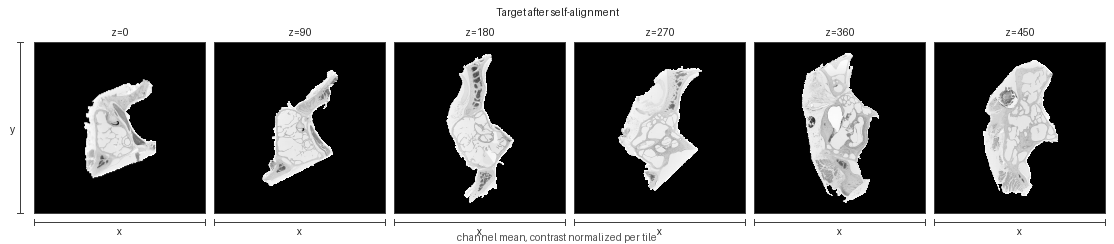

  Atlas-free reconstructed template produced by self-alignment, shown on the target grid.


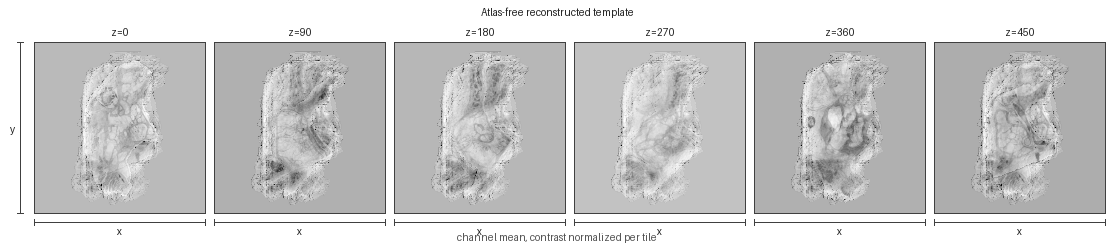

atlas_registration: skipped (0 report image(s))
upsampling: skipped (0 report image(s))


In [11]:
if report_manifest_path.exists():
    report_manifest = json.loads(report_manifest_path.read_text(encoding="utf-8"))
    for stage in report_manifest.get("stages", []):
        gallery = stage.get("gallery", {})
        images = gallery.get("images", [])[:4]
        print(f"{stage.get('name')}: {stage.get('status')} ({gallery.get('selected_count', 0)} report image(s))")
        for image in images:
            image_path = REGISTRATION_OUTPUT / image["path"]
            if image_path.exists():
                print(f"  {image.get('caption', image.get('name', image_path.name))}")
                display(Image(filename=str(image_path), width=760))
else:
    print(f"No report manifest found yet: {report_manifest_path}")

## Step 8: eA2d Self-Alignment Sweep

This optional ladder keeps the dataset, level-7 working resolution, atlas-free operator, and `n_steps=10` fixed while sweeping only `self_alignment.eA2d`. Prefer the smallest value that visibly improves slice alignment without isolated huge jumps or edge-driven motion.


INFO:wsi_pipeline.registration.workflow:Starting EM-LDDMM workflow planning
INFO:wsi_pipeline.registration.workflow:Resolved registration backend: installed:emlddmm
INFO:wsi_pipeline.registration.workflow:Target source resolved to /cis/home/dpadova/Documents/temporal_bone_project/notebook_flatfile_smoke_level7/tissue_sections (prepared-dir)
INFO:wsi_pipeline.registration.workflow:Atlas mode=atlas_free init_mode=none
INFO:wsi_pipeline.registration.workflow:Units atlas=1000.0 target=1.0 working_resolution_um=200.0
INFO:wsi_pipeline.registration.workflow:Downsampling target=[1, 6, 6] atlas=None
INFO:wsi_pipeline.registration.workflow:Pre-resampling policy=sectioned-stack target_native_spacing_um=[16.0, 35.0537109375, 35.0537109375] target_working_spacing_um=[16.0, 210.3232421875, 210.32177734375] target_locked_axes=[0]
INFO:wsi_pipeline.registration.workflow:Pre-resampling note: sectioned-stack policy preserves target axis 0 and applies desired_resolution_um only to in-plane axes.
INFO:ws

starting it 0
starting it 1


/cis/home/dpadova/Documents/git/emlddmm/emlddmm.py:1514: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  A2d = torch.tensor(A2d.detach().clone(),device=device, dtype=dtype)


starting it 2
starting it 3
starting it 4
starting it 5
starting it 6
starting it 7
starting it 8
starting it 9


INFO:wsi_pipeline.registration.workflow:Completed stage: self_alignment in 283.810s
INFO:wsi_pipeline.registration.workflow:Wrote self_alignment artifacts -> /cis/home/dpadova/Documents/temporal_bone_project/notebook_flatfile_smoke_level7/tissue_sections/emlddmm/sweeps/ea2d/eA2d_5e3/self_alignment
INFO:wsi_pipeline.registration.workflow:Skipping stage: atlas_registration (no atlas provided)
INFO:wsi_pipeline.registration.workflow:Skipping stage: upsampling (not requested)
INFO:wsi_pipeline.registration.workflow:Wrote normalized replay command -> /cis/home/dpadova/Documents/temporal_bone_project/notebook_flatfile_smoke_level7/tissue_sections/emlddmm/sweeps/ea2d/eA2d_5e3/reproduce_step5_command.txt
INFO:wsi_pipeline.registration.workflow:Building registration QC report
INFO:wsi_pipeline.registration.report:Wrote registration QC report -> /cis/home/dpadova/Documents/temporal_bone_project/notebook_flatfile_smoke_level7/tissue_sections/emlddmm/sweeps/ea2d/eA2d_5e3/registration_report.html
I

...

/cis/home/dpadova/Documents/git/emlddmm/emlddmm.py:1514: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  A2d = torch.tensor(A2d.detach().clone(),device=device, dtype=dtype)


starting it 2
starting it 3
starting it 4
starting it 5
starting it 6
starting it 7
starting it 8
starting it 9


INFO:wsi_pipeline.registration.workflow:Completed stage: self_alignment in 274.245s
INFO:wsi_pipeline.registration.workflow:Wrote self_alignment artifacts -> /cis/home/dpadova/Documents/temporal_bone_project/notebook_flatfile_smoke_level7/tissue_sections/emlddmm/sweeps/ea2d/eA2d_1e5/self_alignment
INFO:wsi_pipeline.registration.workflow:Skipping stage: atlas_registration (no atlas provided)
INFO:wsi_pipeline.registration.workflow:Skipping stage: upsampling (not requested)
INFO:wsi_pipeline.registration.workflow:Wrote normalized replay command -> /cis/home/dpadova/Documents/temporal_bone_project/notebook_flatfile_smoke_level7/tissue_sections/emlddmm/sweeps/ea2d/eA2d_1e5/reproduce_step5_command.txt
INFO:wsi_pipeline.registration.workflow:Building registration QC report
INFO:wsi_pipeline.registration.report:Wrote registration QC report -> /cis/home/dpadova/Documents/temporal_bone_project/notebook_flatfile_smoke_level7/tissue_sections/emlddmm/sweeps/ea2d/eA2d_1e5/registration_report.html
I

<IPython.core.display.JSON object>

,label,eA2d,status,registration_output,median_translation_um,p95_translation_um,max_translation_um,median_translation_px,p95_translation_px,max_translation_px,p95_rotation_abs_deg,p95_linear_frobenius,present_nonidentity_count,missing_nonidentity_count,present_diff_rms,present_diff_mean_abs,diagnostics_path
0,eA2d_5e3,5000.0,completed,/cis/home/dpadova/Documents/temporal_bone_proj...,1.045639,6.625968,42.682365,0.004972,0.031504,0.202938,0.022170,0.000547,46,0,0.003218,0.000260,/cis/home/dpadova/Documents/temporal_bone_proj...
1,eA2d_1e4,10000.0,completed,/cis/home/dpadova/Documents/temporal_bone_proj...,2.863094,12.513721,88.838494,0.013613,0.059498,0.422393,0.046972,0.001159,46,0,0.006549,0.000551,/cis/home/dpadova/Documents/temporal_bone_proj...
2,eA2d_2e4,20000.0,completed,/cis/home/dpadova/Documents/temporal_bone_proj...,5.548119,24.063475,195.964500,0.026379,0.114413,0.931737,0.106502,0.002629,46,0,0.013838,0.001143,/cis/home/dpadova/Documents/temporal_bone_proj...
3,eA2d_5e4,50000.0,completed,/cis/home/dpadova/Documents/temporal_bone_proj...,10.512536,67.487113,646.163923,0.049983,0.320875,3.072264,0.344411,0.008501,46,0,0.029153,0.002793,/cis/home/dpadova/Documents/temporal_bone_proj...
4,eA2d_1e5,100000.0,completed,/cis/home/dpadova/Documents/temporal_bone_proj...,21.919589,228.293132,967.006686,0.104219,1.085443,4.597749,0.703966,0.017376,46,0,0.044066,0.005281,/cis/home/dpadova/Documents/temporal_bone_proj...


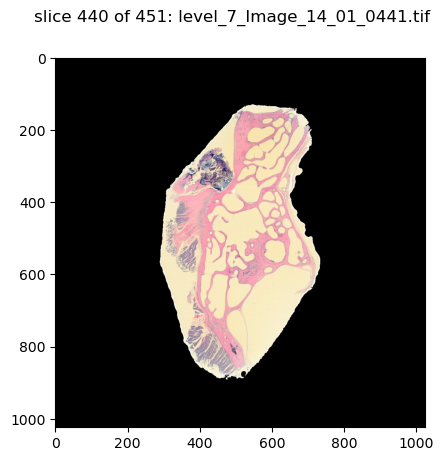

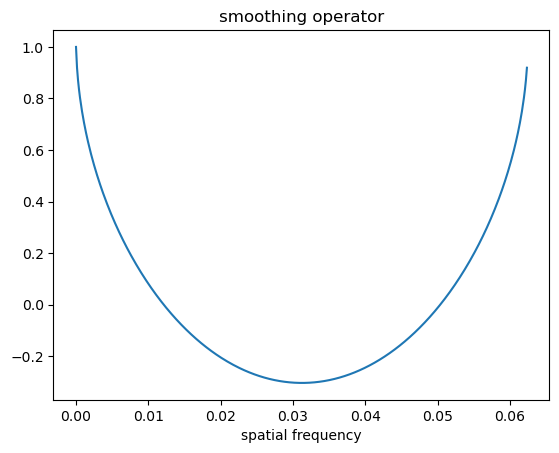

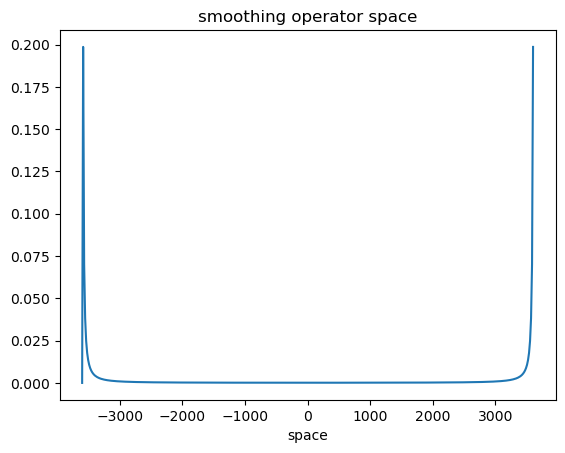

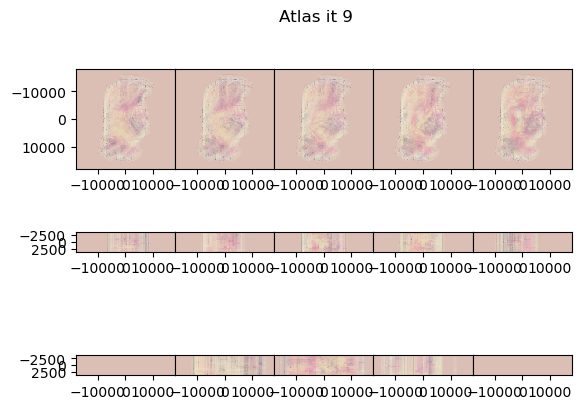

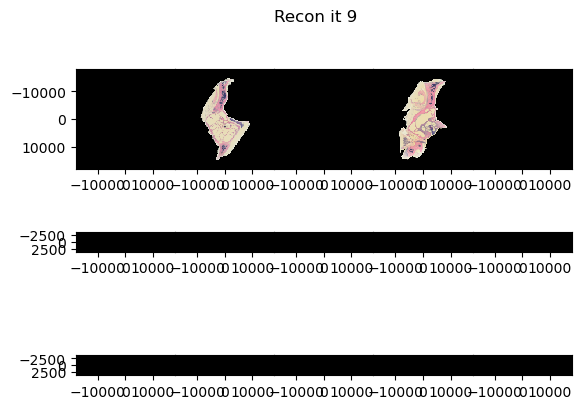

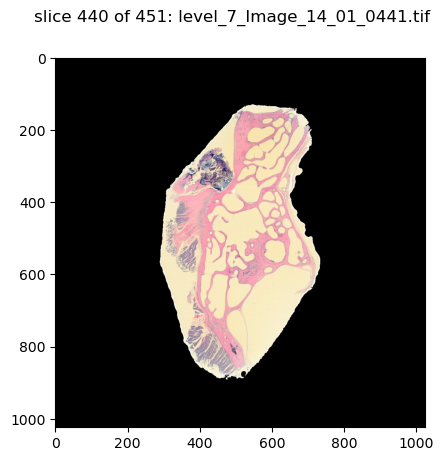

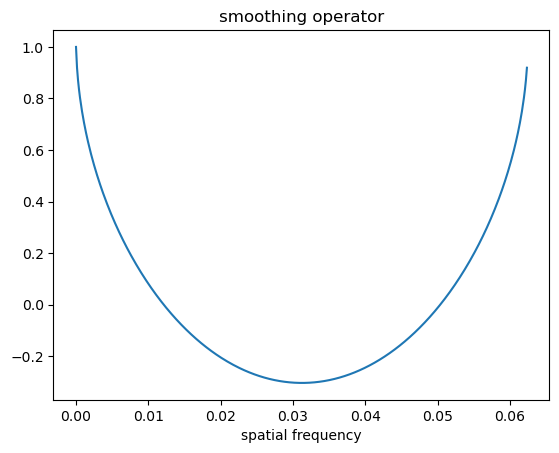

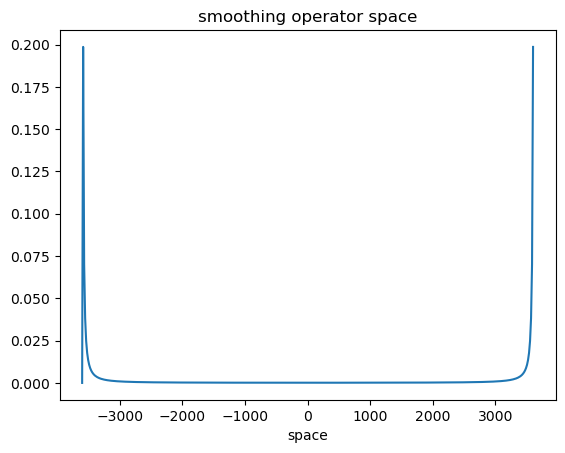

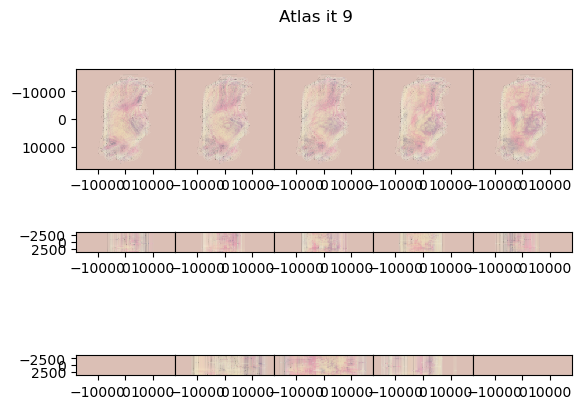

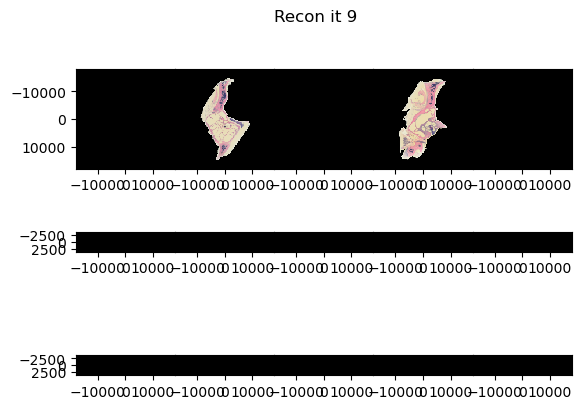

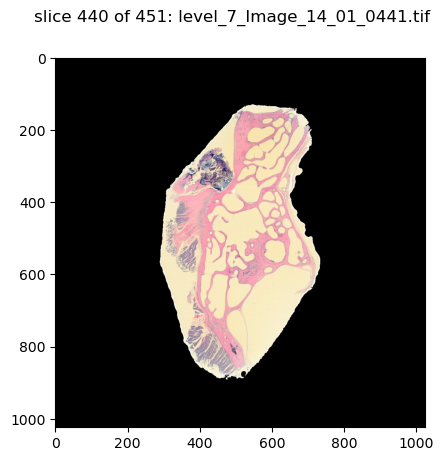

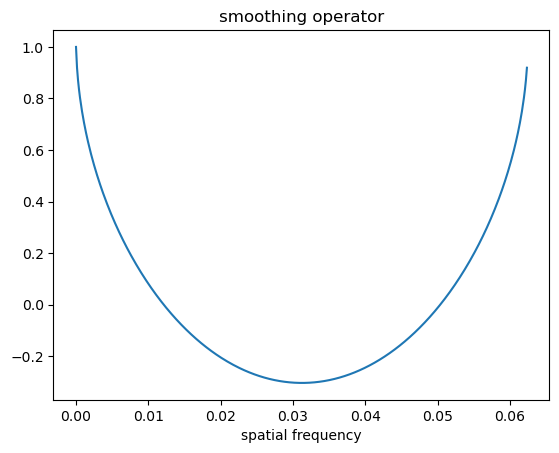

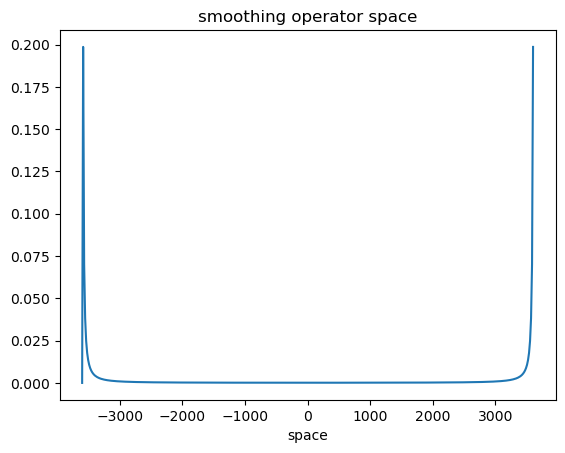

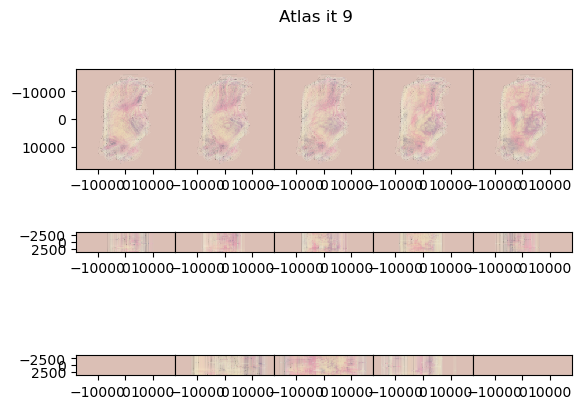

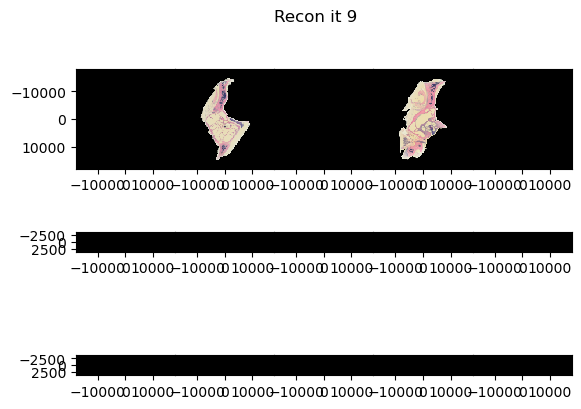

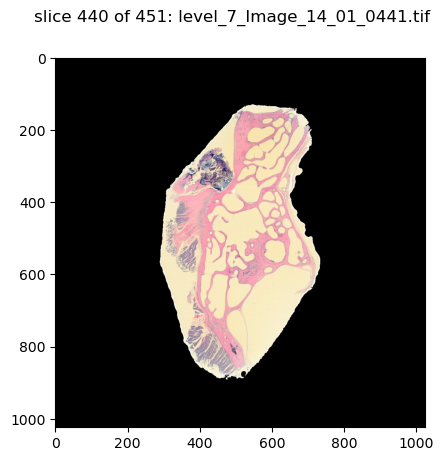

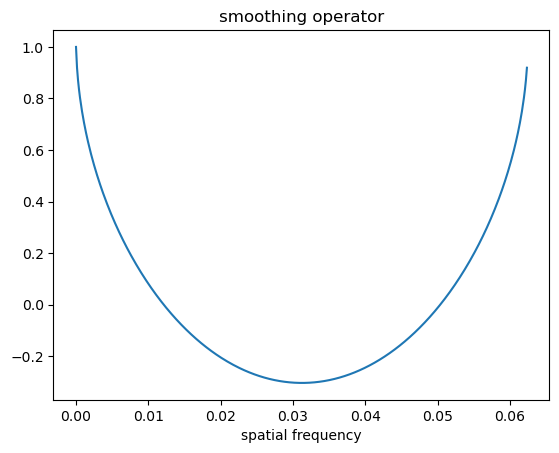

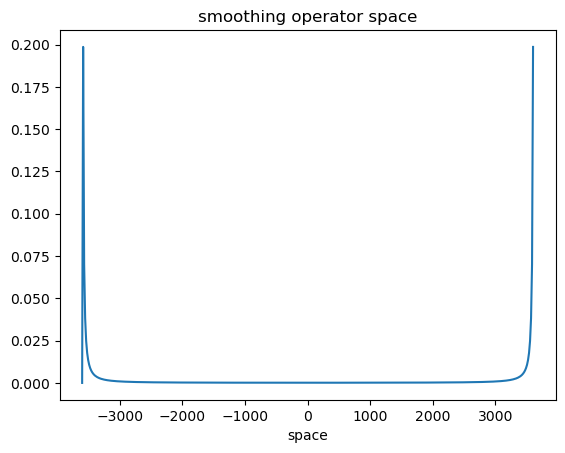

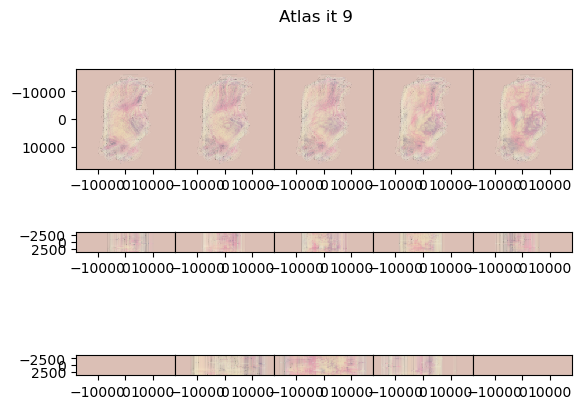

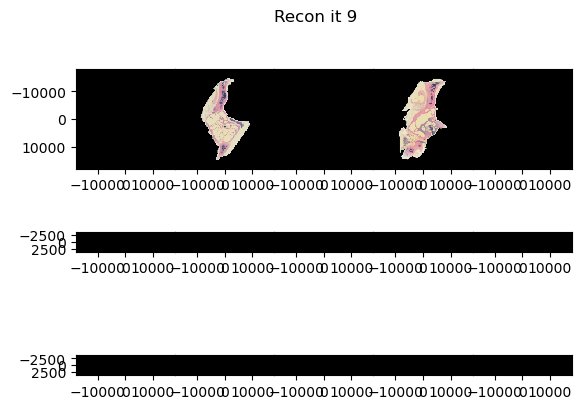

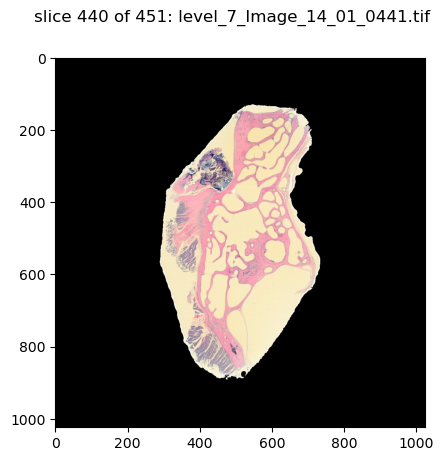

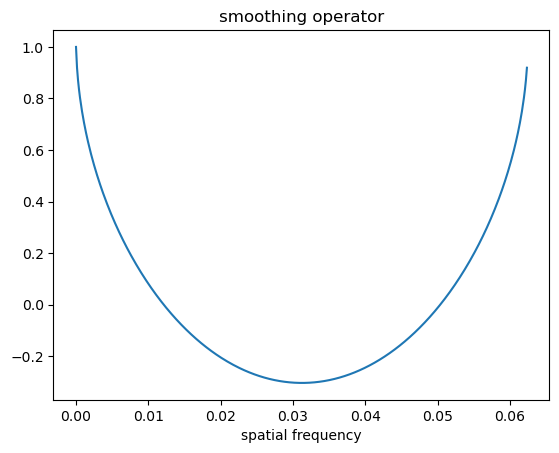

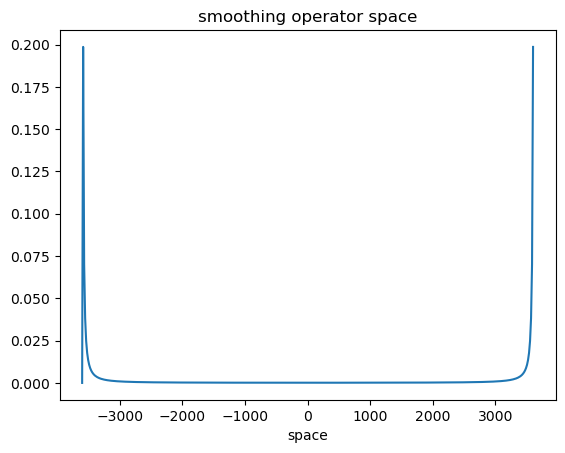

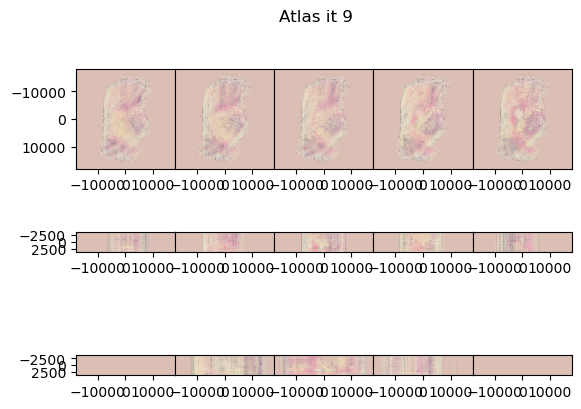

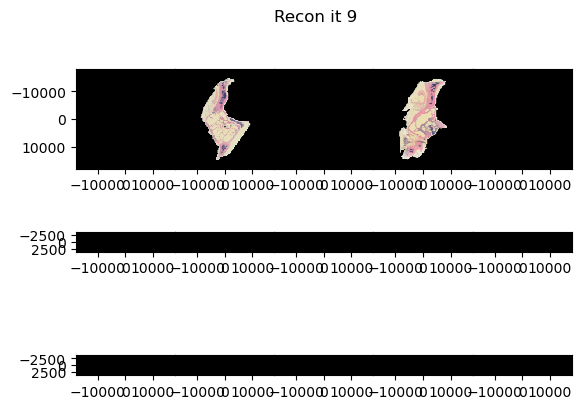

In [12]:
if RUN_EA2D_SWEEP:
    ea2d_sweep = run_ea2d_self_alignment_sweep(
        workflow_kwargs=workflow_kwargs,
        sweep_root=EA2D_SWEEP_OUTPUT,
        values=EA2D_SWEEP_VALUES,
        include_stress_test=EA2D_SWEEP_INCLUDE_STRESS,
        n_steps=10,
        top_n=EA2D_SWEEP_TOP_N,
        dry_run=DRY_RUN,
    )
else:
    ea2d_sweep = summarize_ea2d_sweep(EA2D_SWEEP_OUTPUT)
    if ea2d_sweep is None:
        print("RUN_EA2D_SWEEP is False; set it True to run the eA2d ladder.")
    else:
        print(f"Loaded existing eA2d sweep summary: {ea2d_sweep['summary_path']}")

if ea2d_sweep is not None:
    display(
        JSON(
            {
                "sweep_root": ea2d_sweep.get("sweep_root"),
                "summary_path": ea2d_sweep.get("summary_path"),
                "summary_csv": ea2d_sweep.get("summary_csv"),
                "runs": [run.get("label") for run in ea2d_sweep.get("runs", [])],
            },
            expanded=False,
        )
    )
    sweep_rows = ea2d_sweep.get("summary_rows", [])
    if sweep_rows:
        display(pd.DataFrame(sweep_rows))


eA2d_5e3: /cis/home/dpadova/Documents/temporal_bone_project/notebook_flatfile_smoke_level7/tissue_sections/emlddmm/sweeps/ea2d/eA2d_5e3


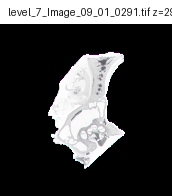

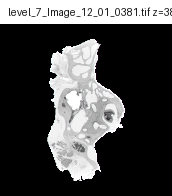

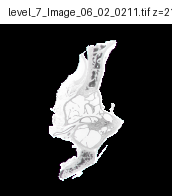

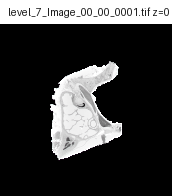

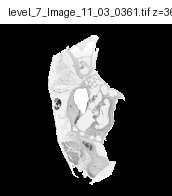

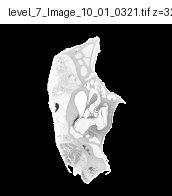

eA2d_1e4: /cis/home/dpadova/Documents/temporal_bone_project/notebook_flatfile_smoke_level7/tissue_sections/emlddmm/sweeps/ea2d/eA2d_1e4


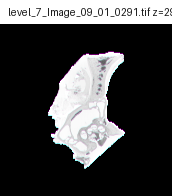

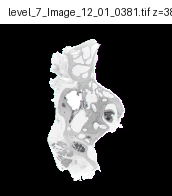

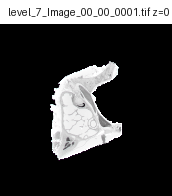

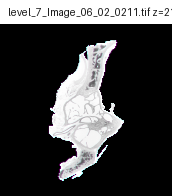

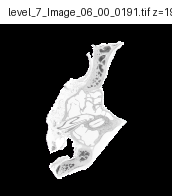

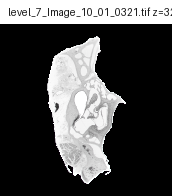

eA2d_2e4: /cis/home/dpadova/Documents/temporal_bone_project/notebook_flatfile_smoke_level7/tissue_sections/emlddmm/sweeps/ea2d/eA2d_2e4


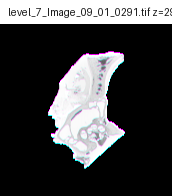

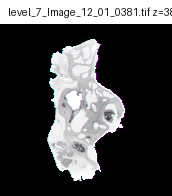

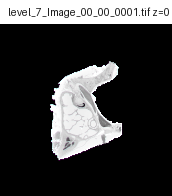

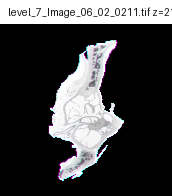

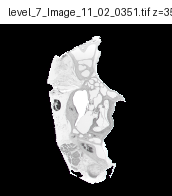

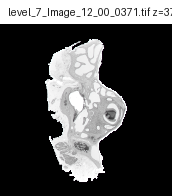

eA2d_5e4: /cis/home/dpadova/Documents/temporal_bone_project/notebook_flatfile_smoke_level7/tissue_sections/emlddmm/sweeps/ea2d/eA2d_5e4


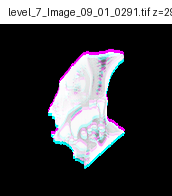

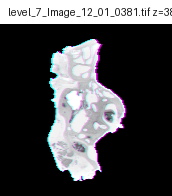

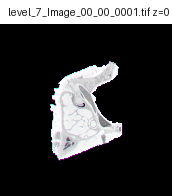

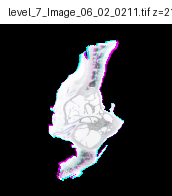

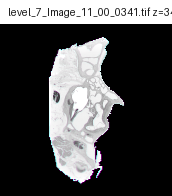

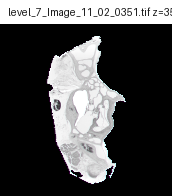

eA2d_1e5: /cis/home/dpadova/Documents/temporal_bone_project/notebook_flatfile_smoke_level7/tissue_sections/emlddmm/sweeps/ea2d/eA2d_1e5


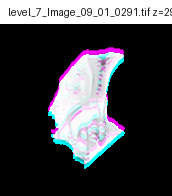

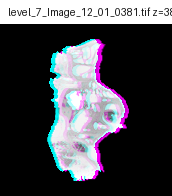

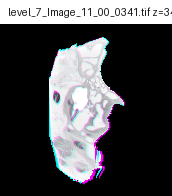

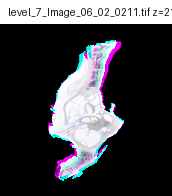

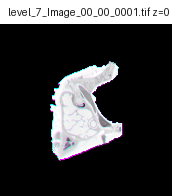

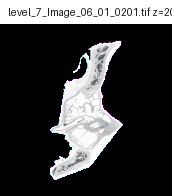

In [13]:
if ea2d_sweep and ea2d_sweep.get("runs"):
    for run in ea2d_sweep["runs"]:
        diagnostics = run.get("diagnostics") or {}
        overlays = diagnostics.get("overlay_images", [])[:EA2D_SWEEP_TOP_N]
        if not overlays:
            continue
        print(f"{run.get('label')}: {run.get('registration_output')}")
        for overlay in overlays:
            display(Image(filename=overlay, width=760))
else:
    print("No eA2d sweep overlays available yet.")


## Step 9: 3D Visualization

Use the same lightweight pattern as the Neuroglancer notebook: prepare a viewer bundle, open Neuroglancer, optionally embed the iframe, and stop the server when finished. The bundle is written under `REGISTRATION_OUTPUT / "visualization"` and can be reused across notebook runs.

Layer meanings:
- `original_slices`: cyan pre-alignment observed slices, when `self_alignment/images/input_target.vtk` is available.
- `registered_slices`: magenta observed slices after self-alignment.
- `aligned_volume`: filled volume when upsampling ran, otherwise the atlas-free reconstructed template.
- `tissue_mask`: a segmentation-style mask layer for 3D shape/surface inspection of the sparse stack.


In [ ]:
from IPython.display import IFrame

from wsi_pipeline.neuroglancer import stop_cors_server
from wsi_pipeline.registration.visualization import (
    open_registration_neuroglancer_view,
    prepare_registration_neuroglancer_bundle,
)

registration_ng_bundle = prepare_registration_neuroglancer_bundle(REGISTRATION_OUTPUT)
display(JSON({
    "bundle_root": str(registration_ng_bundle.root),
    "aligned_volume": str(registration_ng_bundle.aligned_precomputed)
    if registration_ng_bundle.aligned_precomputed
    else None,
    "original_slices": str(registration_ng_bundle.original_precomputed)
    if registration_ng_bundle.original_precomputed
    else "missing; rerun Step 6 to write self_alignment/images/input_target.vtk",
    "registered_slices": str(registration_ng_bundle.registered_precomputed)
    if registration_ng_bundle.registered_precomputed
    else None,
    "tissue_mask": str(registration_ng_bundle.tissue_mask_precomputed)
    if registration_ng_bundle.tissue_mask_precomputed
    else None,
}, expanded=False))

try:
    registration_viewer, registration_httpd = open_registration_neuroglancer_view(
        registration_ng_bundle,
        http_port=8010,
        ng_port=9998,
    )
    display(IFrame(src=registration_viewer.get_viewer_url(), width=1000, height=700))
except ImportError as exc:
    registration_viewer = None
    registration_httpd = None
    print(exc)


<IPython.core.display.JSON object>

### Optional Surface Mesh

Surface mesh generation lives in `wsi_pipeline.surface` and uses the registered Step 5 stack as its input.


In [ ]:
from wsi_pipeline.surface import prepare_registration_surface_mesh

try:
    surface_mesh_path = prepare_registration_surface_mesh(REGISTRATION_OUTPUT)
    print(f"Surface mesh: {surface_mesh_path}")
except ImportError as exc:
    print(exc)


PyVista/VTK are not installed. Install with: pip install -e ".[visualization]"


In [ ]:
# Run this when you are done with the embedded Neuroglancer viewer.
if "registration_httpd" in globals() and registration_httpd is not None:
    stop_cors_server(registration_httpd)
    registration_httpd = None


## Optional Appendix: Between-Slice Upsampling

Between-slice upsampling fills missing planes after the existing alignment stages have produced a stack worth interpolating. Leave it disabled for the first self-alignment pass, inspect QC, then set `UPSAMPLE_BETWEEN_SLICES = True` near the top and rerun the plan plus registration cells.

Use `UPSAMPLE_MODE = "img"` for intensity images. Use `"seg"` only for discrete label-like volumes where nearest-neighbor behavior is desired.

In [15]:
present_indices = [
    int(entry.get("grid_index", idx))
    for idx, entry in enumerate(entries)
    if is_present(entry) and entry.get("grid_index") is not None
]
present_indices = sorted(present_indices)
upsampling_pairs = list(zip(present_indices[:-1], present_indices[1:]))
upsampling_rows = [
    {
        "ind0": ind0,
        "ind1": ind1,
        "gap": ind1 - ind0,
        "missing_planes": max(ind1 - ind0 - 1, 0),
    }
    for ind0, ind1 in upsampling_pairs
]
max_gap = max((row["gap"] for row in upsampling_rows), default=0)
upsampling_config = resolved_plan.workflow_config.get("upsampling", {}) if "resolved_plan" in globals() else {}
upsampling_nt = upsampling_config.get("nt")

preview_payload = {
    "upsampling_enabled": UPSAMPLE_BETWEEN_SLICES,
    "upsampling_mode": UPSAMPLE_MODE,
    "present_slice_count": len(present_indices),
    "pair_count": len(upsampling_rows),
    "max_present_slice_gap": max_gap,
    "configured_nt": upsampling_nt,
    "note": "Set UPSAMPLE_BETWEEN_SLICES=True and rerun the workflow after alignment QC passes.",
}
display(JSON(preview_payload, expanded=True))

if upsampling_rows:
    display(pd.DataFrame(upsampling_rows).head(12))
else:
    print("No adjacent present slice pairs were found in the target manifest.")

<IPython.core.display.JSON object>

,ind0,ind1,gap,missing_planes
0,0,10,10,9
1,10,20,10,9
2,20,30,10,9
3,30,40,10,9
4,40,50,10,9
5,50,60,10,9
6,60,70,10,9
7,70,80,10,9
8,80,90,10,9
9,90,100,10,9


In [16]:
upsampling_dir = REGISTRATION_OUTPUT / "upsampling"
upsampling_metadata_path = upsampling_dir / "upsampling_metadata.json"
upsampling_overview_path = upsampling_dir / "filled_volume_overview.png"

if upsampling_metadata_path.exists():
    display(JSON(json.loads(upsampling_metadata_path.read_text()), expanded=False))
    if upsampling_overview_path.exists():
        display(Image(filename=str(upsampling_overview_path)))
else:
    print(f"No upsampling metadata found yet: {upsampling_metadata_path}")
    print("Run Step 6 with UPSAMPLE_BETWEEN_SLICES=True after self-alignment QC is satisfactory.")

No upsampling metadata found yet: /cis/home/dpadova/Documents/temporal_bone_project/notebook_flatfile_smoke_level7/tissue_sections/emlddmm/upsampling/upsampling_metadata.json
Run Step 6 with UPSAMPLE_BETWEEN_SLICES=True after self-alignment QC is satisfactory.


## Output Layout

The registration directory contains:

- `plan.json` - resolved stage plan and inputs.
- `workflow_summary.json` - executed or dry-run summary.
- `self_alignment/` - self-alignment stage inputs, outputs, and artifacts.
- `upsampling/` - optional between-slice filling outputs when enabled.
- `visualization/` - optional Neuroglancer-precomputed bundle and PyVista mesh outputs.
- `qc_report.md` - optional QC report generated by the workflow.

Atlas-registration outputs are covered by the IEMap workflow in `05b_iemap_atlas_registration.ipynb`.
